<a href="https://colab.research.google.com/github/AlishaRehman-projects/Customer-Segmentation-and-churn-prediction/blob/main/Customer_Segmentation_and_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import and Setup

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

#Loading Data

In [95]:
df=pd.read_excel('/content/Telco_customer_churn.xlsx')
df.sample(4)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
3622,5498-IBWPI,1,United States,California,Guadalupe,93434,"34.936, -120.594655",34.936000,-120.594655,Female,...,One year,Yes,Credit card (automatic),49.40,3251.85,No,0,59,5232,NaN
1341,6686-YPGHK,1,United States,California,Long Beach,90808,"33.823943, -118.111335",33.823943,-118.111335,Male,...,Month-to-month,No,Mailed check,85.50,4042.3,Yes,1,68,3645,Moved
4823,9667-TKTVZ,1,United States,California,Los Osos,93402,"35.279984, -120.824288",35.279984,-120.824288,Female,...,Month-to-month,Yes,Mailed check,54.35,117.05,No,0,71,4916,NaN
4103,6377-KSLXC,1,United States,California,Fair Oaks,95628,"38.652065, -121.25441",38.652065,-121.254410,Male,...,Month-to-month,No,Mailed check,19.95,107.05,No,0,20,4281,NaN


In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [97]:
df.shape

(7043, 33)

#EDA

In [98]:
df['Churn Label'].value_counts()

,count
Churn Label,
No,5174
Yes,1869


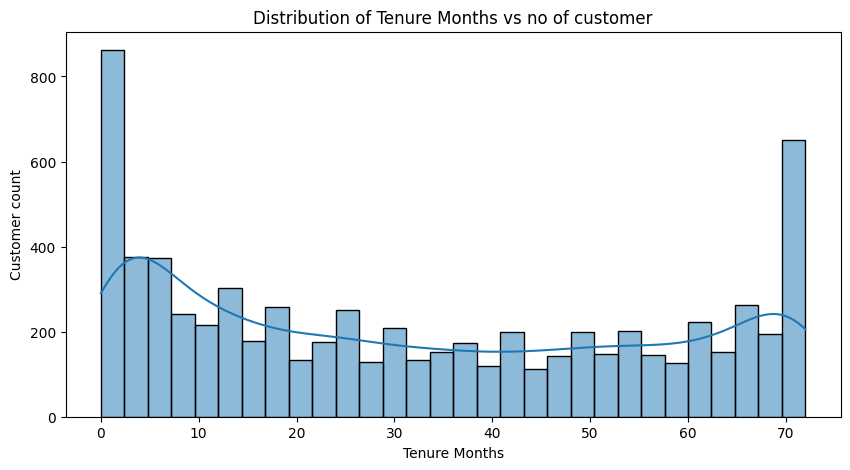

In [99]:
plt.figure(figsize=(10,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [100]:
df['Tenure Months'].max(),df['Tenure Months'].min()

(72, 0)

<Axes: xlabel='Tenure Months', ylabel='Count'>

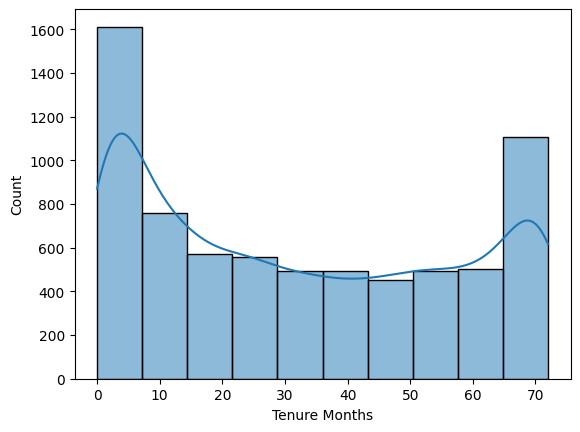

In [102]:
sns.histplot(df['Tenure Months'],bins=10,kde=True)

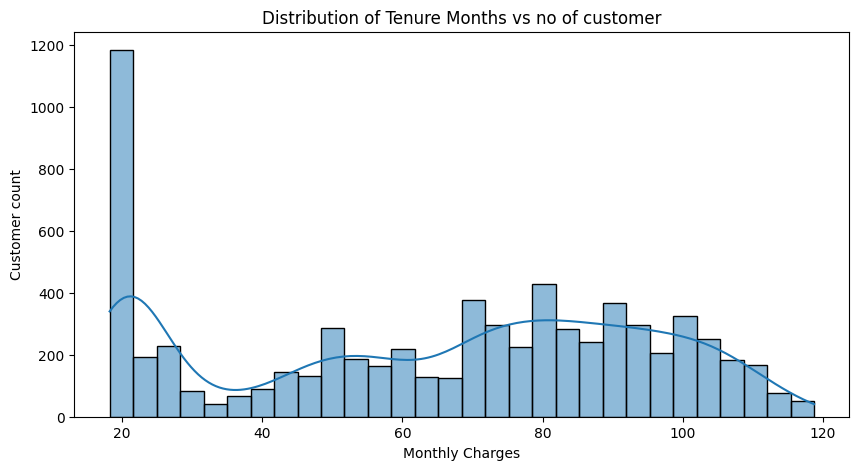

In [103]:
plt.figure(figsize=(10,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Monthly Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no of customer')
plt.show()

In [104]:
df['Monthly Charges'].max(),df['Monthly Charges'].min()

(118.75, 18.25)

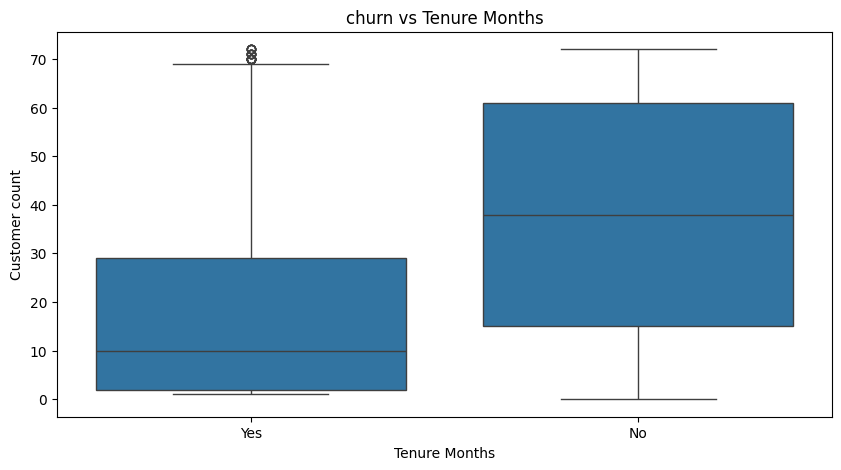

In [105]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Tenure Months',x='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('churn vs Tenure Months')
plt.show()

After 10 month the churn but person availing for 32 months are continuing to availing it

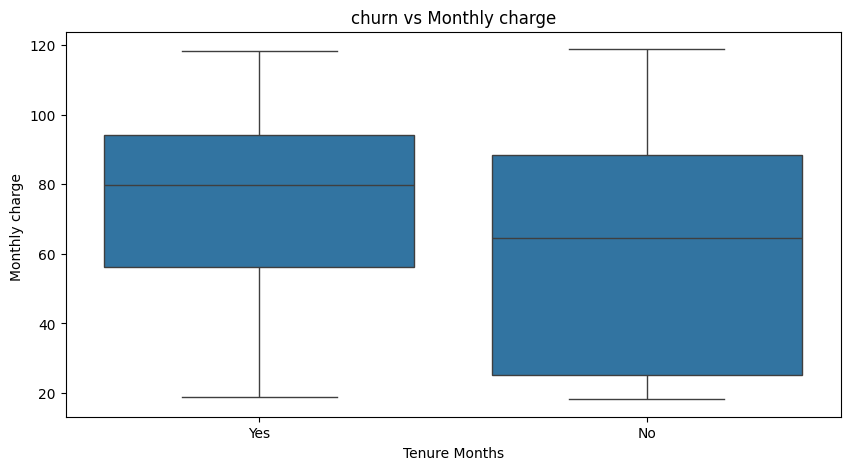

In [106]:
plt.figure(figsize=(10,5))
sns.boxplot(y='Monthly Charges',x='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('Monthly charge ')
plt.title('churn vs Monthly charge')
plt.show()

In [107]:
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [108]:
df[df['Churn Label']=='No']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,25.100
0.50,64.425
0.75,88.400


In [109]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [1]:
df['Contract'].unique()
df['Contract'].value_counts()

NameError: name 'df' is not defined

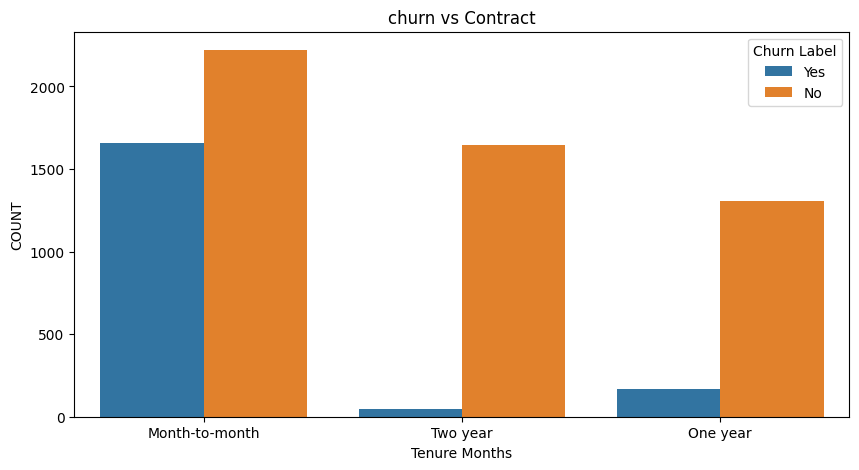

In [112]:
plt.figure(figsize=(10,5))
sns.countplot(x='Contract',hue='Churn Label',data=df)
plt.xlabel('Tenure Months')
plt.ylabel('COUNT')
plt.title('churn vs Contract')
plt.show()
#month to month have high churn rate

In [113]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

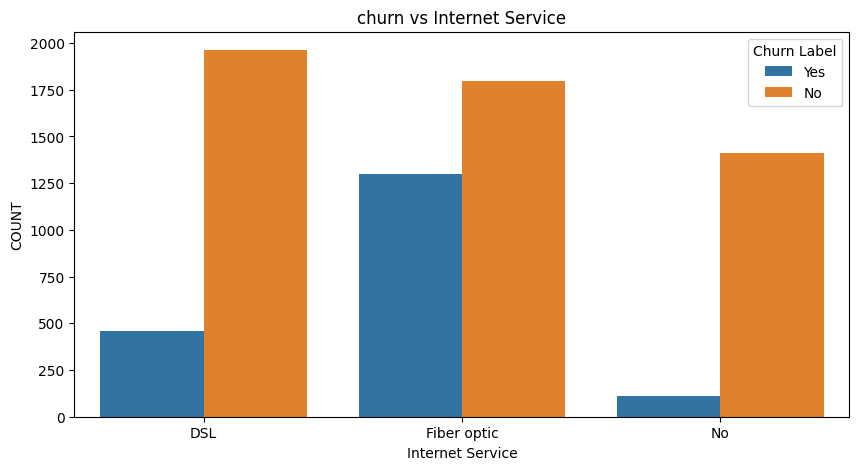

In [114]:
plt.figure(figsize=(10,5))
sns.countplot(x='Internet Service',hue='Churn Label',data=df)
plt.xlabel('Internet Service')
plt.ylabel('COUNT')
plt.title('churn vs Internet Service')
plt.show()
# premiup service have high churn rate

In [115]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

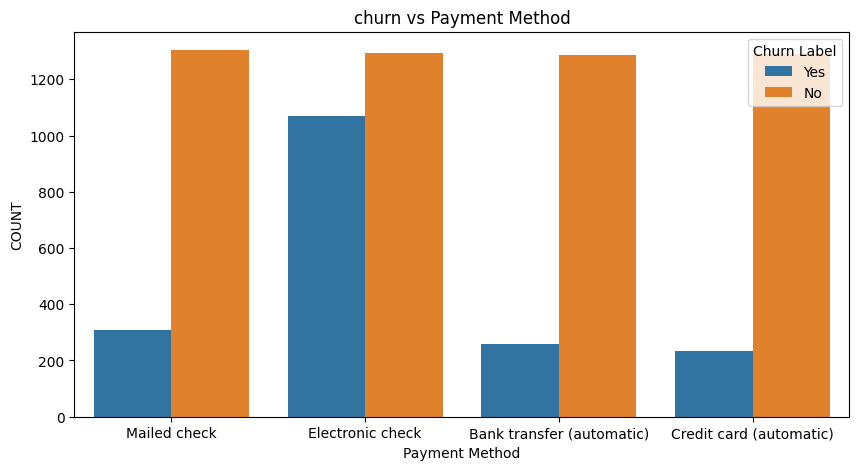

In [116]:
plt.figure(figsize=(10,5))
sns.countplot(x='Payment Method',hue='Churn Label',data=df)
plt.xlabel('Payment Method')
plt.ylabel('COUNT')
plt.title('churn vs Payment Method')
plt.show()
# high churn for electronic check
# inertia automatic -> peopel it will required strong reason for change

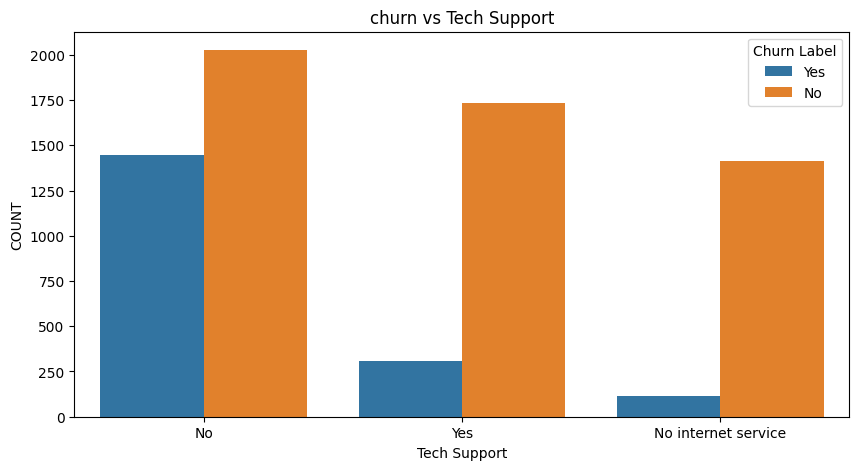

In [117]:
df['Tech Support'].unique()
plt.figure(figsize=(10,5))
sns.countplot(x='Tech Support',hue='Churn Label',data=df)
plt.xlabel('Tech Support')
plt.ylabel('COUNT')
plt.title('churn vs Tech Support')
plt.show()

In [118]:
avg_tenure=df.groupby('Churn Label')['Tenure Months'].mean()
avg_tenure

,Tenure Months
Churn Label,
No,37.569965
Yes,17.979133


In [120]:
num_col=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']

In [121]:
corr_mt=df[num_col].corr()
corr_mt

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


<Axes: >

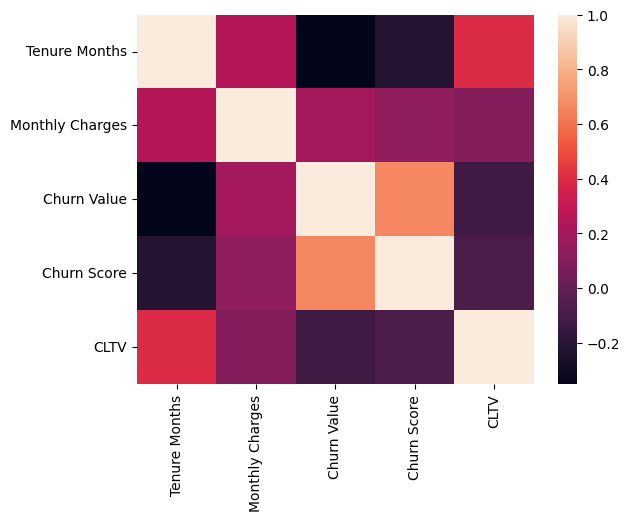

In [122]:

sns.heatmap(corr_mt)

In [123]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'])
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [124]:
Contract_churn =pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
Contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


In [125]:
tech_support_churn =pd.crosstab(df['Tech Support'],df['Churn Label'])
tech_support_churn

Churn Label,No,Yes
Tech Support,,
No,2027,1446
No internet service,1413,113
Yes,1734,310


#Data Cleaning

In [126]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='object')

In [127]:
df['Total Charges'].unique()

array([108.15, 151.65, 820.5, ..., 7362.9, 346.45, 6844.5], dtype=object)

In [128]:
df['Total Charges']=pd.to_numeric(df['Total Charges'],errors='coerce')

In [130]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [131]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [132]:
df[df['Tenure Months']==0]

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,...,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,...,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,...,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN
2667,4367-NUYAO,1,United States,California,Cupertino,95014,"37.306612, -122.080621",37.306612,-122.080621,Male,...,Two year,No,Mailed check,25.75,NaN,No,0,48,4950,NaN
2856,1371-DWPAZ,1,United States,California,Redcrest,95569,"40.363446, -123.835041",40.363446,-123.835041,Female,...,Two year,No,Credit card (automatic),56.05,NaN,No,0,30,4740,NaN
4331,7644-OMVMY,1,United States,California,Los Angeles,90029,"34.089953, -118.294824",34.089953,-118.294824,Male,...,Two year,No,Mailed check,19.85,NaN,No,0,53,2019,NaN
4687,3213-VVOLG,1,United States,California,Sun City,92585,"33.739412, -117.173334",33.739412,-117.173334,Male,...,Two year,No,Mailed check,25.35,NaN,No,0,49,2299,NaN
5104,2520-SGTTA,1,United States,California,Ben Lomond,95005,"37.078873, -122.090386",37.078873,-122.090386,Female,...,Two year,No,Mailed check,20.00,NaN,No,0,27,3763,NaN
5719,2923-ARZLG,1,United States,California,La Verne,91750,"34.144703, -117.770299",34.144703,-117.770299,Male,...,One year,Yes,Mailed check,19.70,NaN,No,0,69,4890,NaN
6772,4075-WKNIU,1,United States,California,Bell,90201,"33.970343, -118.171368",33.970343,-118.171368,Female,...,Two year,No,Mailed check,73.35,NaN,No,0,44,2342,NaN


In [133]:
[7043-7032,(11/7043)]

[11, 0.001561834445548772]

In [134]:
df['Total Charges']=df['Total Charges'].fillna(0)

#Dropping Irrelevant Columns

In [136]:
drop_columns=['CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label',
              'Churn Score','CLTV','Churn Reason']

df=df.drop(columns=drop_columns)
df.shape

In [139]:
df['City'].unique()

array(['Los Angeles', 'Beverly Hills', 'Huntington Park', ..., 'Standish',
       'Tulelake', 'Olympic Valley'], dtype=object)

#One Hot encoding

In [140]:
df=df.drop(columns='City')
df_encode=pd.get_dummies(df,drop_first=True)
df_encode.head()

In [143]:
df_encode.columns

Index(['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Value',
       'Gender_Male', 'Senior Citizen_Yes', 'Partner_Yes', 'Dependents_Yes',
       'Phone Service_Yes', 'Multiple Lines_No phone service',
       'Multiple Lines_Yes', 'Internet Service_Fiber optic',
       'Internet Service_No', 'Online Security_No internet service',
       'Online Security_Yes', 'Online Backup_No internet service',
       'Online Backup_Yes', 'Device Protection_No internet service',
       'Device Protection_Yes', 'Tech Support_No internet service',
       'Tech Support_Yes', 'Streaming TV_No internet service',
       'Streaming TV_Yes', 'Streaming Movies_No internet service',
       'Streaming Movies_Yes', 'Contract_One year', 'Contract_Two year',
       'Paperless Billing_Yes', 'Payment Method_Credit card (automatic)',
       'Payment Method_Electronic check', 'Payment Method_Mailed check'],
      dtype='object')

#Train Test Split

In [144]:
X=df_encode.drop(columns='Churn Value')
y=df_encode['Churn Value']

In [145]:
X.shape,y.shape

((7043, 30), (7043,))

In [182]:
print(X)
print(y)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [146]:
df['Churn Value'].value_counts()

,count
Churn Value,
0,5174
1,1869


In [147]:
# X.info()
(5174/7043)*100,(1869/7043)*100


(73.4630129206304, 26.536987079369588)

#Machine Learning Implementation

In [148]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
X_train.shape,X_test.shape ,y_train.shape,y_test.shape

In [151]:
!pip install CHAID

In [152]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,recall_score,precision_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.over_sampling import SMOTENC
#ML MODELS
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier ,GradientBoostingClassifier,VotingClassifier
from xgboost import XGBClassifier
from CHAID import Tree

**Random Forest Approach**

In [153]:
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [154]:
accuracy_score(y_test,y_pred)
confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

0.7856635911994322

# Balanced Random Forest technique

In [158]:
balance_model=RandomForestClassifier(n_estimators=100,random_state=42,class_weight='balanced')
balance_model.fit(X_train,y_train)
y_pred=balance_model.predict(X_test)

In [159]:
accuracy_score(y_test,y_pred)
confusion_matrix(y_test,y_pred)
print(classification_report(y_test,y_pred))

0.7920511000709723

# Hyper Parameter tuning

In [162]:
hp_balance_model=RandomForestClassifier(n_estimators=300,random_state=42,max_depth=10,class_weight='balanced')
hp_balance_model.fit(X_train,y_train)
y_pred=hp_balance_model.predict(X_test)

In [163]:
accuracy_score(y_test,y_pred)
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7828246983676366

In [166]:
hp_balance_model=RandomForestClassifier(n_estimators=100,
                                        max_depth=3,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train,y_train)
y_pred=hp_balance_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.730305180979418
[[704 305]
 [ 75 325]]
              precision    recall  f1-score   support

           0       0.90      0.70      0.79      1009
           1       0.52      0.81      0.63       400

    accuracy                           0.73      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.79      0.73      0.74      1409



In [167]:
hp_balance_model=RandomForestClassifier(n_estimators=800,
                                        max_depth=131,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train,y_train)
y_pred=hp_balance_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7877927608232789
[[907 102]
 [197 203]]
              precision    recall  f1-score   support

           0       0.82      0.90      0.86      1009
           1       0.67      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



# Feature Selection

**approach feature importance analysis**

<Axes: xlabel='Importance', ylabel='Features'>

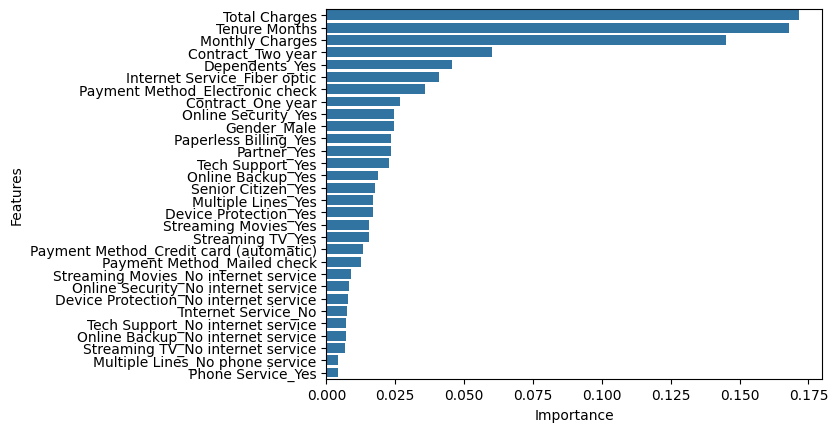

In [168]:
# import panda as pd
fi=pd.DataFrame({
    'Features':X.columns,
    'Importance':hp_balance_model.feature_importances_
})
fi=fi.sort_values('Importance',ascending=False)
# feature Importance

sns.barplot(y=fi['Features'],x=fi['Importance'])

In [169]:
fi.tail(10)

,Features,Importance
29,Payment Method_Mailed check,0.012423
22,Streaming Movies_No internet service,0.008770
12,Online Security_No internet service,0.008113
16,Device Protection_No internet service,0.007753
11,Internet Service_No,0.007324
18,Tech Support_No internet service,0.007014
14,Online Backup_No internet service,0.006989
20,Streaming TV_No internet service,0.006909
8,Multiple Lines_No phone service,0.004193
7,Phone Service_Yes,0.004089


In [170]:
x_select=X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis=1)

In [171]:
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    x_select, y, test_size=0.20, random_state=42, stratify=y)

In [172]:
hp_balance_model=RandomForestClassifier(n_estimators=800,
                                        max_depth=131,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train_sel,y_train_sel)
y_pred=hp_balance_model.predict(X_test_sel)
print(accuracy_score(y_test_sel,y_pred))
print(confusion_matrix(y_test_sel,y_pred))
print(classification_report(y_test_sel,y_pred))

0.7934705464868701
[[928 107]
 [184 190]]
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409



#Approach- combination of tree and depth

In [173]:
n_estimators_list=[100,200,300,400,500]
max_depth_list=[5,10,12,15,20]
result=[]
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    hp_balance_model=RandomForestClassifier(n_estimators=n_trees,
                                        max_depth=depth,
                                        random_state=42,
                                        class_weight='balanced')
    hp_balance_model.fit(X_train_sel,y_train_sel)
    y_pred=hp_balance_model.predict(X_test_sel)
    accuracy=accuracy_score(y_test_sel,y_pred)
    recall=recall_score(y_test_sel,y_pred)
    precision=precision_score(y_test_sel,y_pred)
    result.append({
        'n_trees':n_trees,
        'depth':depth,
        'accuracy':accuracy,
        'recall':recall,
        'precision':precision
    })

In [174]:
rs=pd.DataFrame(result)
rs.sort_values(['recall','accuracy'],inplace=True,ascending=False)
rs

,n_trees,depth,accuracy,recall,precision
10,300,5,0.750177,0.823529,0.518519
15,400,5,0.745919,0.823529,0.513333
5,200,5,0.746629,0.820856,0.514238
20,500,5,0.746629,0.820856,0.514238
0,100,5,0.749468,0.818182,0.517766
21,500,10,0.775727,0.735294,0.558943
6,200,10,0.772179,0.735294,0.553320
11,300,10,0.773598,0.729947,0.556008
16,400,10,0.772889,0.729947,0.554878
1,100,10,0.770759,0.727273,0.551724


In [175]:
hp_balance_model=RandomForestClassifier(n_estimators=500,
                                        max_depth=15,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train_sel,y_train_sel)
y_pred=hp_balance_model.predict(X_test_sel)
print(accuracy_score(y_test_sel,y_pred))
print(confusion_matrix(y_test_sel,y_pred))
print(classification_report(y_test_sel,y_pred))

0.7934705464868701
[[891 144]
 [147 227]]
              precision    recall  f1-score   support

           0       0.86      0.86      0.86      1035
           1       0.61      0.61      0.61       374

    accuracy                           0.79      1409
   macro avg       0.74      0.73      0.73      1409
weighted avg       0.79      0.79      0.79      1409



In [176]:
hp_balance_model=RandomForestClassifier(n_estimators=300,
                                        max_depth=10,
                                        random_state=42,
                                        class_weight='balanced')
hp_balance_model.fit(X_train_sel,y_train_sel)
y_pred=hp_balance_model.predict(X_test_sel)
print(accuracy_score(y_test_sel,y_pred))
print(confusion_matrix(y_test_sel,y_pred))
print(classification_report(y_test_sel,y_pred))

0.7735982966643009
[[817 218]
 [101 273]]
              precision    recall  f1-score   support

           0       0.89      0.79      0.84      1035
           1       0.56      0.73      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



In [177]:
from sklearn.model_selection import cross_val_score
final_rf=RandomForestClassifier(n_estimators=300,
                                        max_depth=10,
                                        random_state=42,
                                        class_weight='balanced')


In [186]:
final_rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [187]:
cv_accuracy=cross_val_score(final_rf,X,y,cv=5,scoring='accuracy')
print(cv_accuracy)
print(cv_accuracy.mean())


[0.76721079 0.79772889 0.76224273 0.78551136 0.78409091]
0.7793569343183432


In [188]:
cv_accuracy=cross_val_score(final_rf,X,y,cv=5,scoring='recall')
print(cv_accuracy)
print(cv_accuracy.mean())


[0.70855615 0.76470588 0.74064171 0.74331551 0.71045576]
0.7335350030823931


In [183]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

In [190]:
y_prob = final_rf.predict_proba(X_test)

In [193]:
churn_probability = y_prob[:,1]
fpr, tpr, threshold = roc_curve(y_test, churn_probability)
auc_score = roc_auc_score(y_test, churn_probability)
print(auc_score)

0.857104806739346


The model achieved an ROC-AUC score of 0.857, indicating that it can effectively distinguish between churn and non-churn customers.

# Customer Segmentation

In [195]:
y_prob1 = final_rf.predict_proba(X_test)
churn_prob = y_prob1[:,1]
y_prob1 = final_rf.predict_proba(X_test)
y_prob = final_rf.predict_proba(X)
churn_probability = y_prob[:,1]

In [196]:
segmentation_data=pd.DataFrame({
  'Tenure Months':X['Tenure Months'],
  'Monthly Charges':X['Monthly Charges'],
  'Total Charges':X['Total Charges'],
  'Churn Probability':churn_probability})

In [198]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
0,2,53.85,108.15,0.676963
1,2,70.70,151.65,0.796013
2,8,99.65,820.50,0.805827
3,28,104.80,3046.05,0.563031
4,49,103.70,5036.30,0.517474
...,...,...,...,...
7038,72,21.15,1419.40,0.003587
7039,24,84.80,1990.50,0.082095
7040,72,103.20,7362.90,0.049001
7041,11,29.60,346.45,0.302367


#Implementation of k-means

In [199]:
from sklearn.preprocessing import StandardScaler

In [201]:
scaled_data=StandardScaler().fit_transform(segmentation_data)
print(scaled_data[:5])

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


#Elbow Method (Optimal K)

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

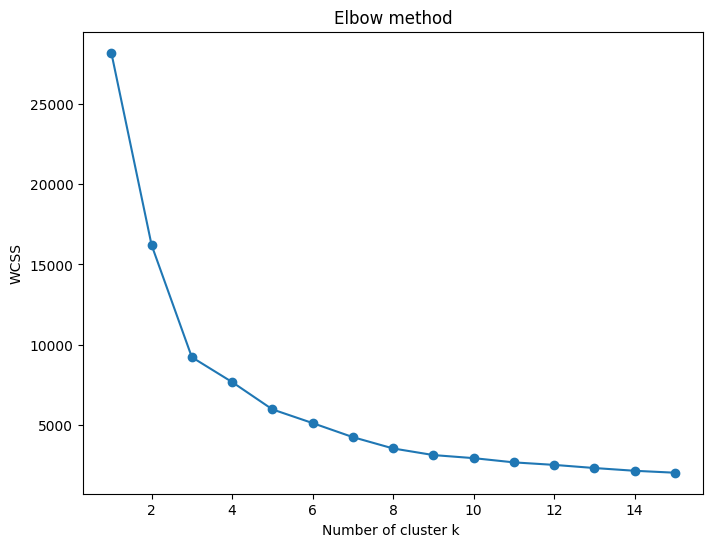

In [202]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.title('Elbow method')
plt.show()

In [203]:
kmeans=KMeans(n_clusters=3,random_state=42)

In [204]:
clusters=kmeans.fit_predict(scaled_data)

In [205]:
segmentation_data['Cluster']=clusters

In [206]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [207]:
cluster_summary

,Tenure Months,Monthly Charges,Total Charges,Churn Probability
Cluster,,,,
0,32.051471,32.845761,1047.702141,0.120599
1,10.957752,71.961298,884.069671,0.691383
2,58.398884,90.430986,5278.001674,0.230647


In [208]:
cluster_names={
    0:'Budget Loyal Customers',
    1:'High Risk New Customers',
    2:'Loyal Premium Customers'
}

In [209]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)

In [210]:
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,1,High Risk New Customers
1,2,70.70,151.65,0.796013,1,High Risk New Customers
2,8,99.65,820.50,0.805827,1,High Risk New Customers
3,28,104.80,3046.05,0.563031,1,High Risk New Customers
4,49,103.70,5036.30,0.517474,2,Loyal Premium Customers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.082095,0,Budget Loyal Customers
7040,72,103.20,7362.90,0.049001,2,Loyal Premium Customers
7041,11,29.60,346.45,0.302367,0,Budget Loyal Customers


Conclusion

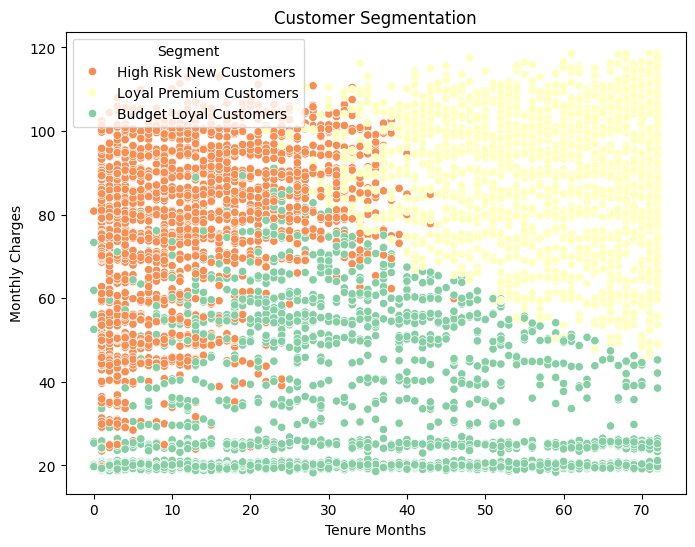

In [221]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months', y= 'Monthly Charges',hue='Cluster Segment', data = segmentation_data, palette = 'Spectral')
plt.title('Customer Segmentation')
plt.xlabel('Tenure Months')
plt.ylabel('Monthly Charges')
plt.legend(title='Segment')
plt.show()

In [223]:

segmentation_data['Churn Probability'] = (
    1 - segmentation_data['Tenure Months'] /
    segmentation_data['Tenure Months'].max()
)


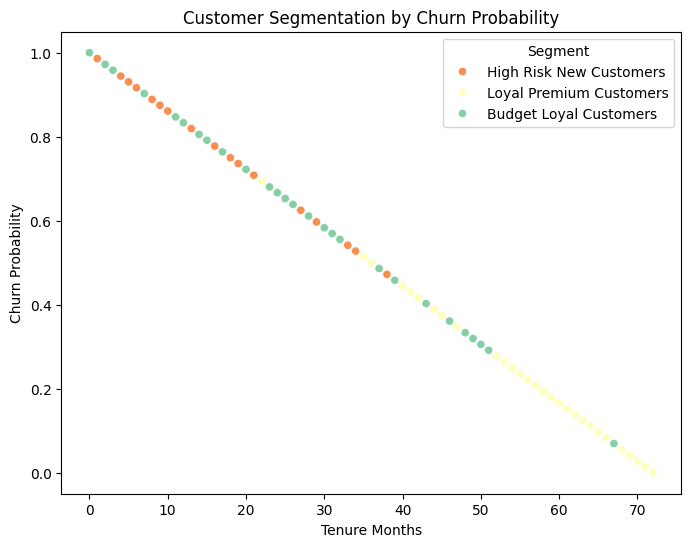

In [224]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='Tenure Months', y= 'Churn Probability',hue='Cluster Segment', data = segmentation_data, palette = 'Spectral')
plt.title('Customer Segmentation by Churn Probability')
plt.xlabel('Tenure Months')
plt.ylabel('Churn Probability')
plt.legend(title='Segment')
plt.show()